In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/kaggle/input/datasets/oktayrdeki/heart-disease/heart_disease.csv')

In [4]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [5]:
df.shape

(10000, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [7]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

In [8]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.corr(numeric_only = True)

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
Age,1.000000,-0.020781,0.011371,0.011229,0.002481,-0.008112,-0.006019,0.008779,-0.007084
Blood Pressure,-0.020781,1.000000,-0.012026,0.005405,0.001153,0.008108,-0.011991,-0.010137,-0.003244
Cholesterol Level,0.011371,-0.012026,1.000000,0.022002,0.011195,0.001451,0.000060,-0.017564,-0.006285
BMI,0.011229,0.005405,0.022002,1.000000,-0.001029,0.005354,0.006437,-0.016525,0.003583
Sleep Hours,0.002481,0.001153,0.011195,-0.001029,1.000000,0.002166,0.008586,0.002067,-0.020280
Triglyceride Level,-0.008112,0.008108,0.001451,0.005354,0.002166,1.000000,0.008086,-0.006413,-0.005727
Fasting Blood Sugar,-0.006019,-0.011991,0.000060,0.006437,0.008586,0.008086,1.000000,0.010479,-0.020404
CRP Level,0.008779,-0.010137,-0.017564,-0.016525,0.002067,-0.006413,0.010479,1.000000,-0.010088
Homocysteine Level,-0.007084,-0.003244,-0.006285,0.003583,-0.020280,-0.005727,-0.020404,-0.010088,1.000000


In [11]:
df['Alcohol Consumption'].value_counts()

Alcohol Consumption
Medium    2500
Low       2488
High      2426
Name: count, dtype: int64

In [12]:
missing_percent = df['Alcohol Consumption'].isnull().mean() * 100
print(missing_percent)

25.86


In [13]:
num_cols = [
    'Age',
    'Blood Pressure',
    'Cholesterol Level',
    'BMI',
    'Sleep Hours',
    'Triglyceride Level',
    'Fasting Blood Sugar',
    'CRP Level',
    'Homocysteine Level'
]

In [14]:
cat_cols = [
    'Gender',
    'Exercise Habits',
    'Smoking',
    'Family Heart Disease',
    'Diabetes',
    'High Blood Pressure',
    'Low HDL Cholesterol',
    'High LDL Cholesterol',
    'Alcohol Consumption',
    'Stress Level',
    'Sugar Consumption',
    'Heart Disease Status'
]

In [15]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
df.isnull().sum()

Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64

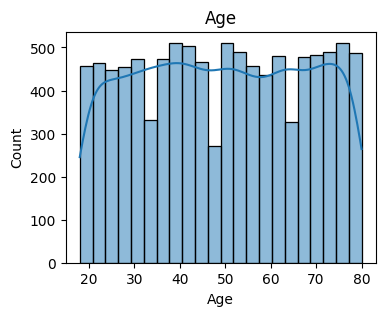

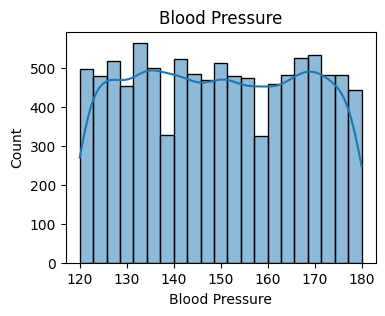

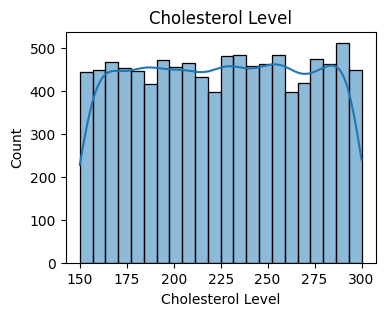

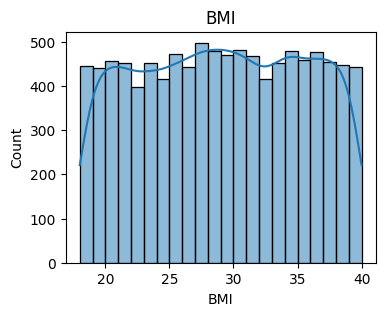

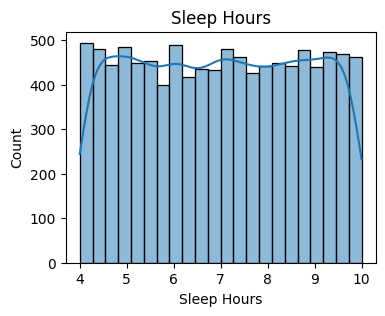

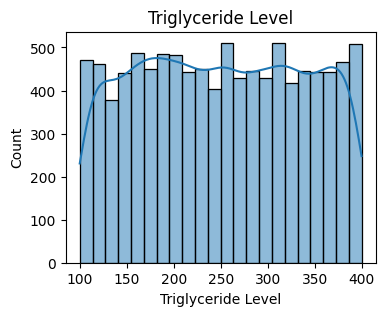

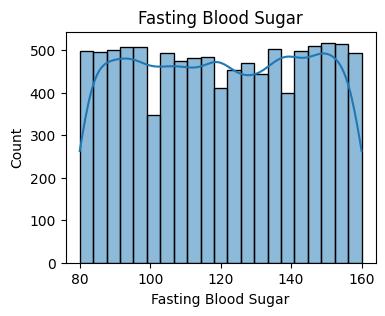

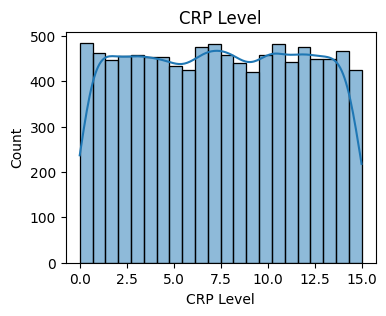

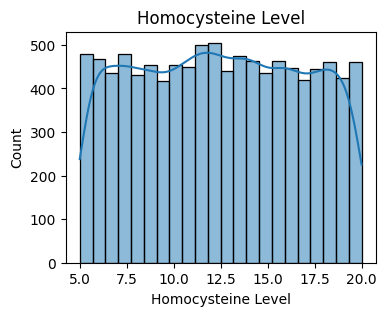

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in num_cols:
    plt.figure(figsize = (4, 3))
    sns.histplot(df[col], kde = True)
    plt.title(col)
    plt.savefig(f"{col}_histplot.png", dpi=300, bbox_inches='tight')
    plt.show()

In [18]:
X = df.drop('Heart Disease Status', axis = 1)
y = df['Heart Disease Status']

In [19]:
X = pd.get_dummies(X, drop_first = True)

In [20]:
y = y.map({'No' : 0, 'Yes' : 1})

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 21,
    stratify = y
)

In [66]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 9)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=9)

In [68]:
y_pred = knn.predict(X_test_scaled)

In [69]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1600
           1       0.22      0.02      0.04       400

    accuracy                           0.79      2000
   macro avg       0.51      0.50      0.46      2000
weighted avg       0.68      0.79      0.71      2000

[[1572   28]
 [ 392    8]]


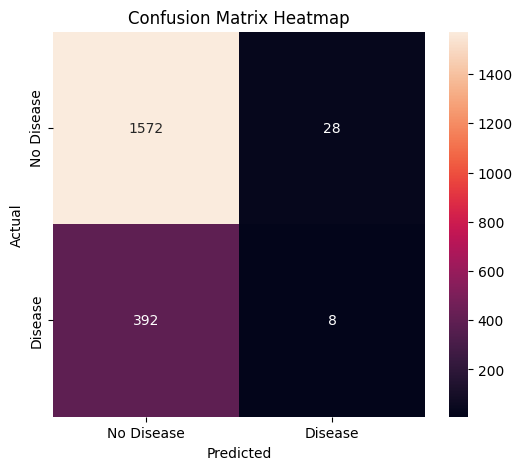

In [73]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()